# Fintech Pulse — Layoff & Stock Reaction Analysis
Queries against `hive_metastore_pulse.fintech_pulse_marts`

## 0. Imports & Helpers

In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

TABLE = "hive_metastore_pulse.fintech_pulse_marts"

COLORS = {
    "rewarded": "#2ecc71",
    "punished": "#e74c3c",
    "neutral":  "#95a5a6",
    "bar":      "#3498db",
    "line":     "#e67e22",
    "accent":   "#9b59b6",
}

def styled_bar(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=10)

## 1. Market Reaction — Rewarded vs Punished

In [0]:
df_reaction = spark.sql(f"""
    SELECT
        market_reaction,
        COUNT(*)                                                     AS events,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1)          AS pct_of_total,
        ROUND(AVG(pct_laid_off), 1)                                  AS avg_pct_workforce_cut
    FROM {TABLE}.layoff_stock_reactions
    GROUP BY market_reaction
    ORDER BY events DESC
""").toPandas()

display(df_reaction)

market_reaction,events,pct_of_total,avg_pct_workforce_cut
Strong Reward (>+5%),39,44.8,19.1
Strong Punishment (<-5%),22,25.3,22.6
Mild Reward (0-5%),17,19.5,13.7
Mild Punishment (0-5%),9,10.3,16.0


/home/spark-389de514-14ba-4e75-b7a2-fc/.ipykernel/321/command-7196488822053228-790145310:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/home/spark-389de514-14ba-4e75-b7a2-fc/.ipykernel/321/command-7196488822053228-790145310:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


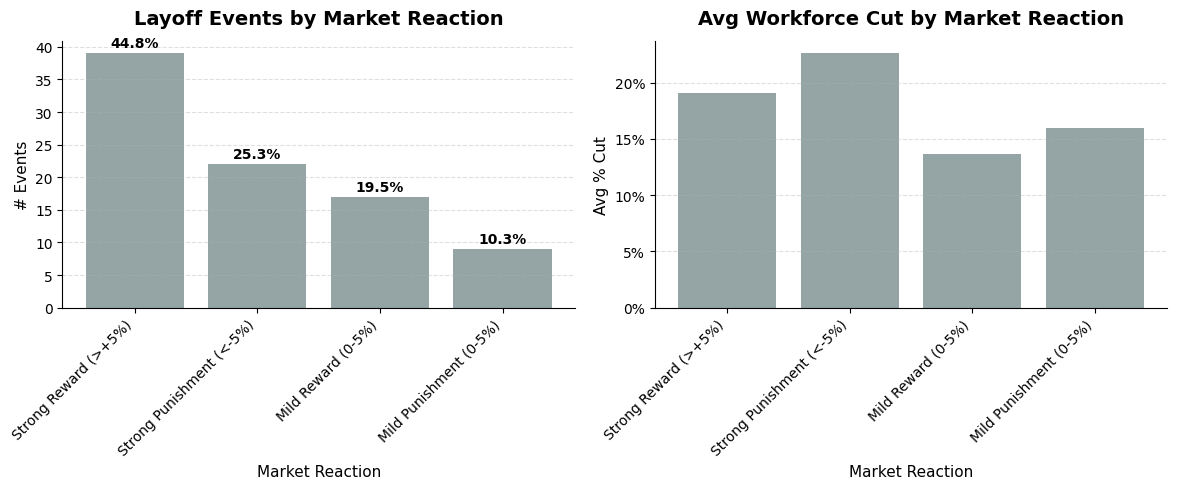

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

reaction_colors = [
    COLORS.get(r.lower(), COLORS['neutral'])
    for r in df_reaction['market_reaction']
]

# Event count
axes[0].bar(df_reaction['market_reaction'], df_reaction['events'], color=reaction_colors)
for bar, pct in zip(axes[0].patches, df_reaction['pct_of_total']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f"{pct}%", ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
styled_bar(axes[0], 'Layoff Events by Market Reaction', 'Market Reaction', '# Events')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Avg workforce cut
axes[1].bar(df_reaction['market_reaction'], df_reaction['avg_pct_workforce_cut'], color=reaction_colors)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
styled_bar(axes[1], 'Avg Workforce Cut by Market Reaction', 'Market Reaction', 'Avg % Cut')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 2. Layoff Severity vs 30-Day Stock Return

In [0]:
df_severity = spark.sql(f"""
    SELECT
        severity,
        COUNT(*)                                                             AS events,
        ROUND(AVG(pct_change_30d), 2)                                        AS avg_30d_return,
        ROUND(AVG(CASE WHEN stock_went_up THEN 1.0 ELSE 0.0 END) * 100, 1)  AS pct_rewarded
    FROM {TABLE}.layoff_stock_reactions
    GROUP BY severity
    ORDER BY avg_30d_return DESC
""").toPandas()

display(df_severity)

severity,events,avg_30d_return,pct_rewarded
Minor (<5%),12,6.39,83.3
Unknown,34,4.2,76.5
Moderate (5-15%),20,1.94,55.0
Severe (30%+),5,1.18,60.0
Major (15-30%),16,-4.92,37.5


/home/spark-389de514-14ba-4e75-b7a2-fc/.ipykernel/321/command-7196488822053231-2196561729:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/home/spark-389de514-14ba-4e75-b7a2-fc/.ipykernel/321/command-7196488822053231-2196561729:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


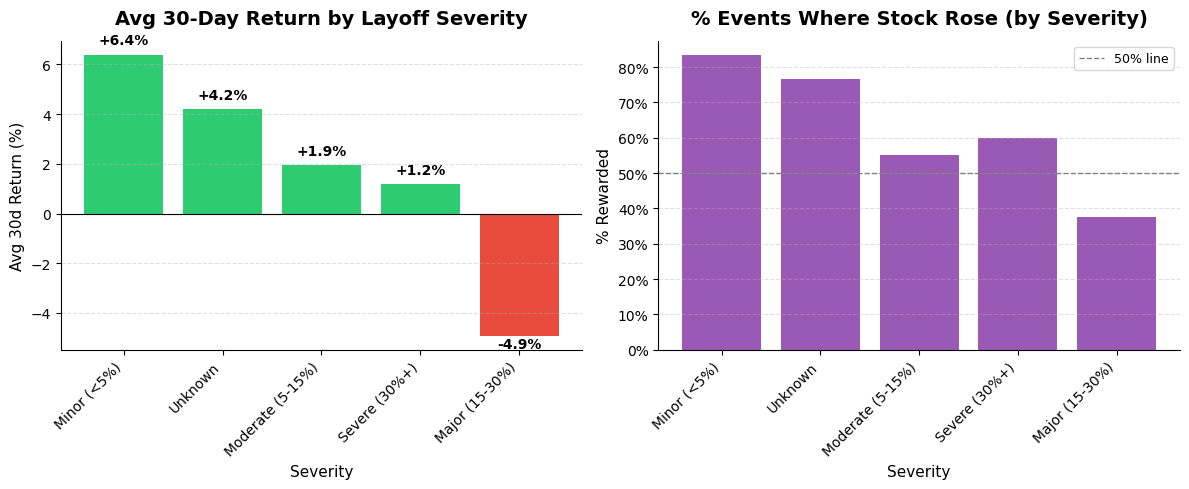

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Avg 30d return (colour by sign)
bars = axes[0].bar(df_severity['severity'], df_severity['avg_30d_return'],
                   color=[COLORS['rewarded'] if v >= 0 else COLORS['punished']
                          for v in df_severity['avg_30d_return']])
for bar in bars:
    v = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 v + (0.3 if v >= 0 else -0.6),
                 f"{v:+.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
styled_bar(axes[0], 'Avg 30-Day Return by Layoff Severity', 'Severity', 'Avg 30d Return (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# % rewarded
axes[1].bar(df_severity['severity'], df_severity['pct_rewarded'], color=COLORS['accent'])
axes[1].axhline(50, color='grey', linewidth=1, linestyle='--', label='50% line')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
axes[1].legend(fontsize=9)
styled_bar(axes[1], '% Events Where Stock Rose (by Severity)', 'Severity', '% Rewarded')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 3. Industry Summary

In [0]:
df_industry = spark.sql(f"""
    SELECT * FROM {TABLE}.industry_summary
    ORDER BY avg_30d_return DESC
""").toPandas()

display(df_industry)

industry,total_events,total_jobs_cut,avg_30d_return,median_30d_return,best_30d,worst_30d,"round((avg(CASE WHEN stock_went_up THEN 1.0 ELSE 0.0 END) * 100), 1)"
Finance,3,1203,9.81,4.33,32.29,-7.2,66.7
Software Development,4,15900,8.59,9.71,12.38,0.85,100.0
Media,6,2790,6.94,2.81,20.25,-9.03,66.7
Infrastructure,3,13950,4.04,7.1,7.7,-2.68,66.7
Retail,11,30980,3.51,4.57,21.44,-12.35,72.7
Consumer,21,40112,2.36,4.72,20.48,-33.37,66.7
Transportation,9,10539,-0.94,-1.61,33.75,-22.41,33.3
Other,11,19705,-1.6,3.39,7.96,-20.13,54.5
Sales,3,2000,-1.88,0.97,7.31,-13.93,66.7
Semiconductors,3,395,-3.68,2.42,7.71,-21.18,66.7


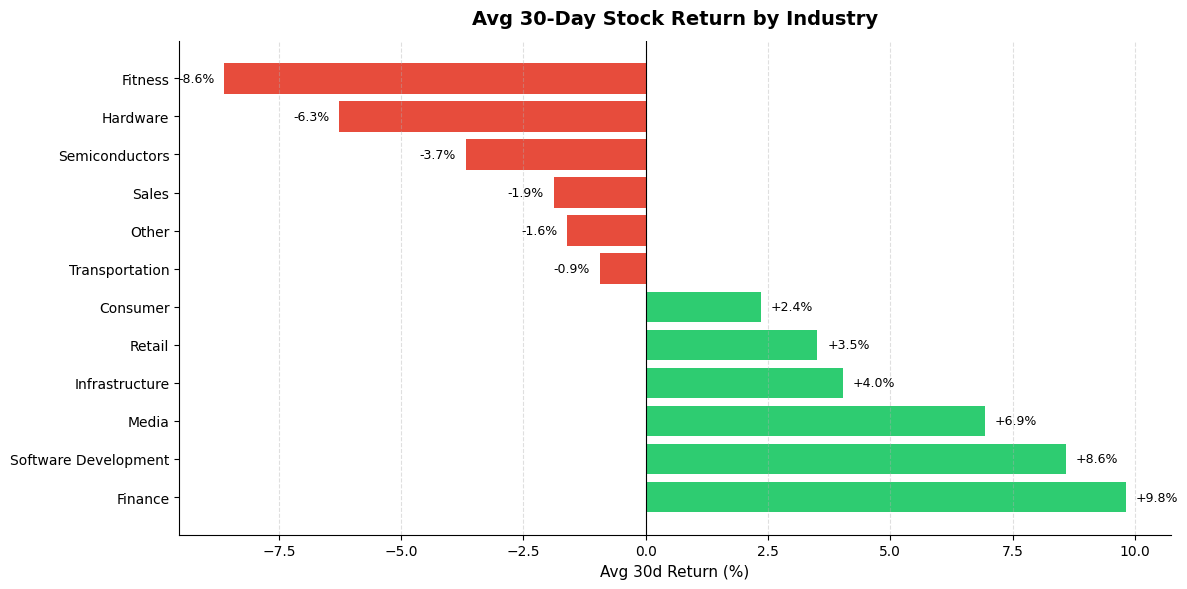

In [0]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = [COLORS['rewarded'] if v >= 0 else COLORS['punished']
          for v in df_industry['avg_30d_return']]
ax.barh(df_industry['industry'], df_industry['avg_30d_return'], color=colors)

for bar in ax.patches:
    w = bar.get_width()
    ax.text(w + (0.2 if w >= 0 else -0.2),
            bar.get_y() + bar.get_height() / 2,
            f"{w:+.1f}%", va='center',
            ha='left' if w >= 0 else 'right', fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Avg 30-Day Stock Return by Industry', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Avg 30d Return (%)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 4. Yearly Trend

In [0]:
df_yearly = spark.sql(f"""
    SELECT * FROM {TABLE}.yearly_trend
    ORDER BY year
""").toPandas()

display(df_yearly)

year,events,total_jobs_cut,avg_30d_return,pct_rewarded,yoy_return_delta,yoy_pct_rewarded_delta
2020,5,8507,2.28,20.0,null,null
2022,17,35777,-3.76,47.1,-6.04,27.1
2023,17,59158,6.82,76.5,10.58,29.4
2024,31,35591,2.02,74.2,-4.8,-2.3
2025,17,42358,3.48,64.7,1.46,-9.5


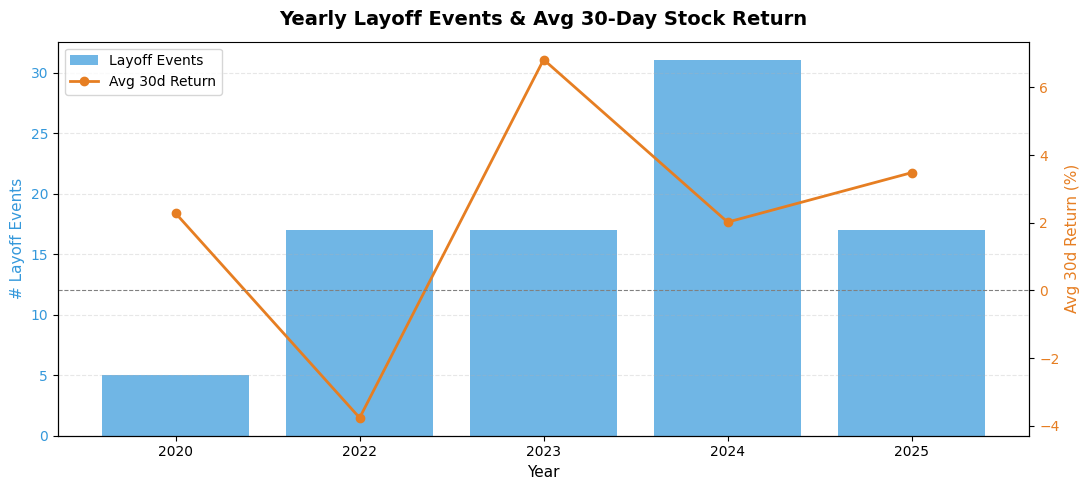

In [0]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(df_yearly['year'].astype(str), df_yearly['events'],
        color=COLORS['bar'], alpha=0.7, label='Layoff Events')
ax1.set_ylabel('# Layoff Events', fontsize=11, color=COLORS['bar'])
ax1.tick_params(axis='y', labelcolor=COLORS['bar'])

ax2.plot(df_yearly['year'].astype(str), df_yearly['avg_30d_return'],
         color=COLORS['line'], marker='o', linewidth=2, label='Avg 30d Return')
ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Avg 30d Return (%)', fontsize=11, color=COLORS['line'])
ax2.tick_params(axis='y', labelcolor=COLORS['line'])

ax1.set_title('Yearly Layoff Events & Avg 30-Day Stock Return', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Year', fontsize=11)
ax1.spines[['top']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Top 10 Biggest Stock Gains After Layoff

In [0]:
df_top10 = spark.sql(f"""
    SELECT
        company_name,
        ticker,
        announced_date,
        total_layoffs,
        ROUND(pct_laid_off, 1)   AS pct_cut,
        ROUND(pct_change_30d, 1) AS return_30d
    FROM {TABLE}.layoff_stock_reactions
    ORDER BY pct_change_30d DESC
    LIMIT 10
""").toPandas()

display(df_top10)

company_name,ticker,announced_date,total_layoffs,pct_cut,return_30d
Coinbase,COIN,2023-01-10,950,20.0,37.9
Uber,UBER,2020-05-06,3700,14.0,33.8
Robinhood,HOOD,2023-06-26,150,7.0,32.3
Palantir,PLTR,2025-03-27,120,null,27.3
Amazon,AMZN,2023-01-04,8000,2.0,21.4
Meta,META,2025-04-24,100,null,20.5
Netflix,NFLX,2022-06-23,300,3.0,20.3
Spotify,SPOT,2023-01-23,600,6.0,20.1
Peloton,PTON,2024-05-02,400,15.0,16.6
Google,GOOGL,2025-06-24,75,null,15.2


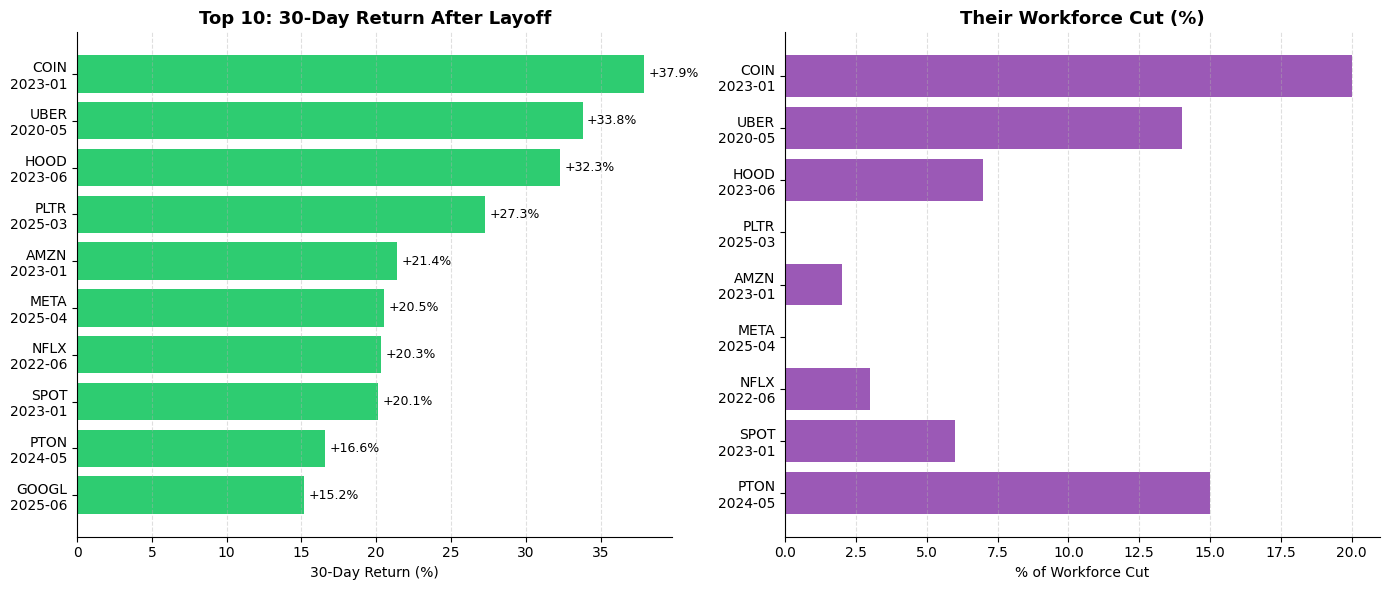

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

label = df_top10['ticker'] + '\n' + df_top10['announced_date'].astype(str).str[:7]

# 30-day return
axes[0].barh(label[::-1], df_top10['return_30d'][::-1], color=COLORS['rewarded'])
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"+{bar.get_width():.1f}%", va='center', fontsize=9)
axes[0].set_title('Top 10: 30-Day Return After Layoff', fontsize=13, fontweight='bold')
axes[0].set_xlabel('30-Day Return (%)')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# % workforce cut
axes[1].barh(label[::-1], df_top10['pct_cut'][::-1], color=COLORS['accent'])
axes[1].set_title('Their Workforce Cut (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% of Workforce Cut')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## 6. Monthly Events & Rolling 3-Month Avg Return

In [0]:
df_monthly = spark.sql(f"""
    WITH monthly AS (
        SELECT
            DATE_TRUNC('month', announced_date) AS month,
            COUNT(*)                             AS events,
            AVG(pct_change_30d)                  AS avg_30d
        FROM {TABLE}.layoff_stock_reactions
        GROUP BY DATE_TRUNC('month', announced_date)
    )
    SELECT
        month,
        events,
        ROUND(avg_30d, 2) AS monthly_avg,
        ROUND(AVG(avg_30d) OVER (
            ORDER BY month
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ), 2) AS rolling_3m_avg
    FROM monthly
    ORDER BY month
""").toPandas()

df_monthly['month'] = pd.to_datetime(df_monthly['month'])
df_monthly['month_label'] = df_monthly['month'].dt.strftime('%b %Y')
display(df_monthly)

month,events,monthly_avg,rolling_3m_avg,month_label
2020-04-01T00:00:00.000Z,1,-8.22,-8.22,Apr 2020
2020-05-01T00:00:00.000Z,3,7.08,-0.57,May 2020
2020-06-01T00:00:00.000Z,1,-1.61,-0.92,Jun 2020
2022-02-01T00:00:00.000Z,1,-39.33,-11.29,Feb 2022
2022-04-01T00:00:00.000Z,1,-7.2,-16.05,Apr 2022
2022-05-01T00:00:00.000Z,1,-9.03,-18.52,May 2022
2022-06-01T00:00:00.000Z,2,11.91,-1.44,Jun 2022
2022-07-01T00:00:00.000Z,2,11.06,4.65,Jul 2022
2022-08-01T00:00:00.000Z,3,-7.91,5.02,Aug 2022
2022-09-01T00:00:00.000Z,1,-18.85,-5.24,Sep 2022


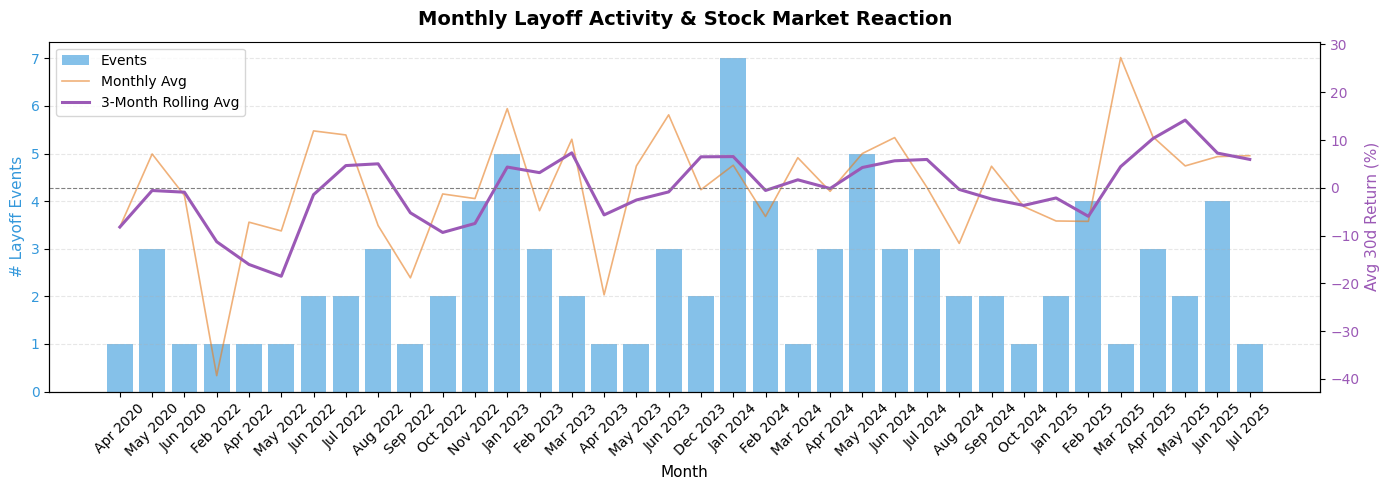

In [0]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(df_monthly['month_label'], df_monthly['events'],
        color=COLORS['bar'], alpha=0.6, label='Events')
ax1.set_ylabel('# Layoff Events', fontsize=11, color=COLORS['bar'])
ax1.tick_params(axis='y', labelcolor=COLORS['bar'])

ax2.plot(df_monthly['month_label'], df_monthly['monthly_avg'],
         color=COLORS['line'], linewidth=1.2, alpha=0.6, label='Monthly Avg')
ax2.plot(df_monthly['month_label'], df_monthly['rolling_3m_avg'],
         color=COLORS['accent'], linewidth=2.2, label='3-Month Rolling Avg')
ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Avg 30d Return (%)', fontsize=11, color=COLORS['accent'])
ax2.tick_params(axis='y', labelcolor=COLORS['accent'])

ax1.set_title('Monthly Layoff Activity & Stock Market Reaction', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Month', fontsize=11)
ax1.spines[['top']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()